In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import plotly.express as px

In [6]:
data_merged = pd.read_csv("../data/merged.csv")
data_merged.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,absences_mat,G1_mat,G2_mat,G3_mat,failures_por,paid_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,2.0,7.0,10.0,10.0,0.0,yes,4.0,13.0,13.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,...,NaN,NaN,NaN,NaN,1.0,no,2.0,8.0,9.0,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,...,2.0,8.0,6.0,5.0,0.0,no,2.0,13.0,11.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,...,8.0,14.0,13.0,13.0,0.0,no,8.0,14.0,13.0,12.0
4,GP,F,15,R,GT3,T,2,4,services,health,...,2.0,10.0,9.0,8.0,0.0,no,2.0,10.0,11.0,10.0


In [ ]:
data_numeric = data_merged

In [12]:
data = data_merged.copy().select_dtypes(include='number')
data = data.dropna()

In [33]:
data.head()

,age,Medu,Fedu,traveltime,studytime,failures_mat,famrel,freetime,goout,Dalc,...,health,absences_mat,G1_mat,G2_mat,G3_mat,failures_por,absences_por,G1_por,G2_por,G3_por
0,15,1,1,2,4,1.0,3,1,2,1,...,1,2.0,7.0,10.0,10.0,0.0,4.0,13.0,13.0,13.0
2,15,1,1,1,2,2.0,3,3,4,2,...,5,2.0,8.0,6.0,5.0,0.0,2.0,13.0,11.0,11.0
3,15,2,2,1,1,0.0,4,3,1,1,...,2,8.0,14.0,13.0,13.0,0.0,8.0,14.0,13.0,12.0
4,15,2,4,1,3,0.0,4,3,2,1,...,5,2.0,10.0,9.0,8.0,0.0,2.0,10.0,11.0,10.0
5,15,3,3,2,3,2.0,4,2,1,2,...,3,8.0,10.0,10.0,10.0,0.0,2.0,13.0,13.0,13.0


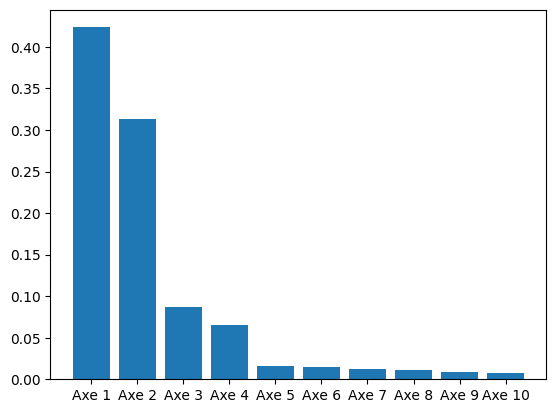

array([0.42360226, 0.73671589, 0.82415149, 0.88897057, 0.9053877 ,
       0.92005586, 0.93253674, 0.94392863, 0.95302597, 0.9610524 ])

In [22]:
cls = PCA(n_components=10) 
pcs = cls.fit_transform(data) 
cls.components_
plt.bar([f"Axe {i+1}" for i in range(10)], cls.explained_variance_ratio_) 
plt.show()
np.cumsum(cls.explained_variance_ratio_)

In [24]:

def add_labels(x, y, labels, ax=None):
    """Ajoute les étiquettes `labels` aux endroits définis par `x` et `y`."""

    if ax is None:
        ax = plt.gca()
    for x, y, label in zip(x, y, labels):
        ax.annotate(
            label, [x, y], xytext=(10, -5), textcoords="offset points",
        )

    return ax

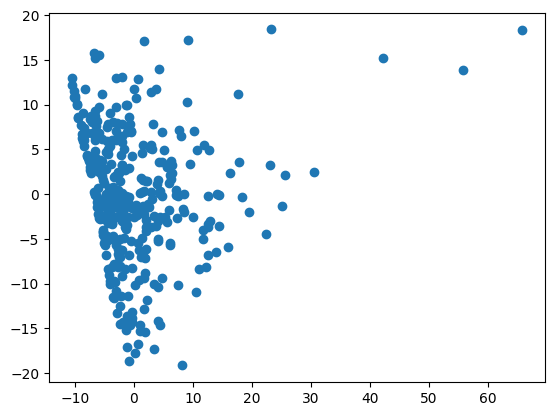

In [27]:
# Représentation dans le premier plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 1]) 
# add_labels(pcs[:, 0], pcs[:, 1], data.index) 
plt.show()

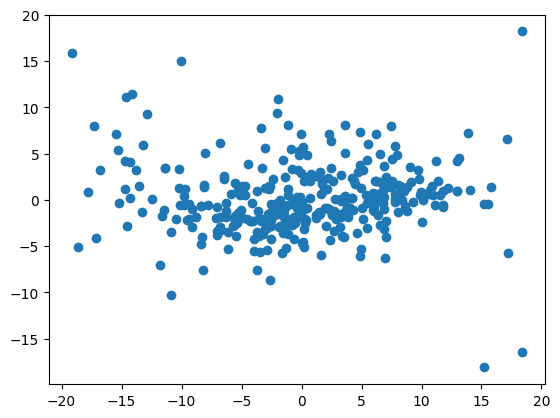

In [ ]:
# Représentation dans le deuxième plan factoriel
plt.scatter(pcs[:, 1], pcs[:, 2]) 
plt.show()

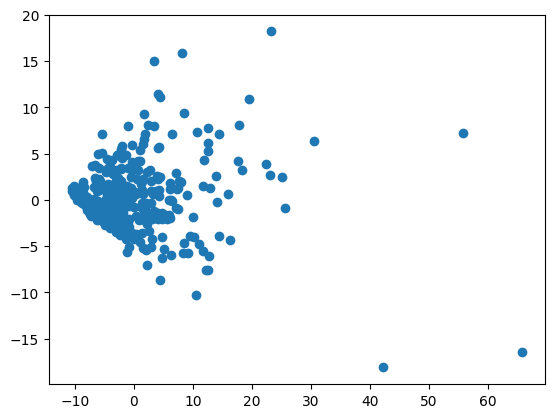

In [29]:
# Représentation dans le troisième plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 2]) 
plt.show()

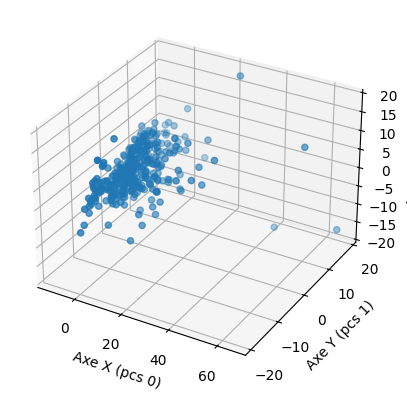

In [54]:
# Visualisation en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2])

ax.set_xlabel('Axe X (pcs 0)')
ax.set_ylabel('Axe Y (pcs 1)')
ax.set_zlabel('Axe Z (pcs 2)')

plt.show()

In [ ]:
# En version interactive 3d
df = pd.DataFrame(pcs[:, :3], columns=['pcs 0', 'pcs 1', 'pcs 2'])

fig = px.scatter_3d(df, x='pcs 0', y='pcs 1', z='pcs 2')
fig.show()

In [ ]:
# Transformation en distances (pour ensuite faire une AFTD dessus)
X = data.copy() 

# standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcul de la matrice de dissimilarité (avec la distance euclidienne)
matrice_dissimilarite = pairwise_distances(X_scaled, metric='euclidean')
df_distances = pd.DataFrame(matrice_dissimilarite, index=data.index, columns=data.index)

print(df_distances.head())

        0         2         3         4         5         6         7    \
0  0.000000  5.942969  5.650061  5.628687  4.527268  5.792594  6.591871   
2  5.942969  0.000000  6.579748  5.636571  5.156302  6.160522  5.399060   
3  5.650061  6.579748  0.000000  4.877891  5.173035  4.416440  7.421165   
4  5.628687  5.636571  4.877891  0.000000  4.810962  1.744639  4.839787   
5  4.527268  5.156302  5.173035  4.810962  0.000000  4.530542  4.439375   

        8         9         10   ...       650       653       654       656  \
0  4.671652  6.054192  5.384836  ...  9.975221  6.753560  7.835660  7.741999   
2  4.708441  7.271868  6.229541  ...  8.007519  6.346752  6.702235  8.212040   
3  5.197485  5.097474  5.097061  ...  9.183850  5.496485  6.148332  6.463176   
4  3.953358  6.330359  3.017453  ...  8.183039  5.841531  6.160497  7.586769   
5  4.576440  5.270460  5.154597  ...  8.341112  6.151544  5.918494  6.745928   

        658       660       663       664       665       666  
0  5

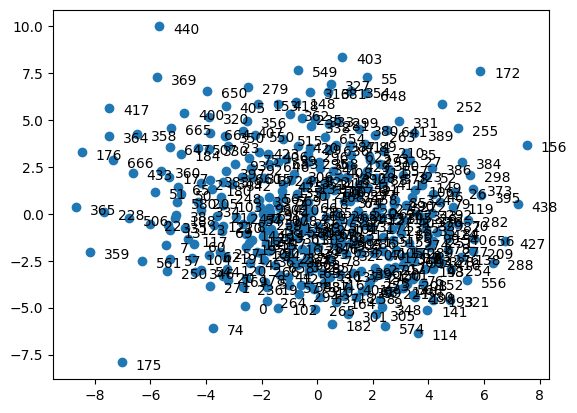

In [38]:
# AFTD
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances)
plt.scatter(*dist.T) 
add_labels(dist[:, 0], dist[:, 1], df_distances.index) 
plt.show()

In [39]:
from scipy.spatial.distance import cdist
def plot_Shepard(mds_model, plot=True):
    """Affiche le diagramme de Shepard et retourne un couple contenant les
    dissimilarités originales et les distances apprises par le
    modèle.
    """

    assert isinstance(mds_model, MDS)

    # Inter-distances apprises
    dist = cdist(mds_model.embedding_, mds_model.embedding_)
    idxs = np.tril_indices_from(dist, k=-1)
    dist_mds = dist[idxs]

    # Inter-distances d'origine
    dist = mds_model.dissimilarity_matrix_
    dist_orig = dist[idxs]

    dists = np.column_stack((dist_orig, dist_mds))

    if plot:
        f, ax = plt.subplots()
        range = [dists.min(), dists.max()]
        ax.plot(range, range, 'r--')
        ax.scatter(*dists.T)
        ax.set_xlabel('Dissimilarités')
        ax.set_ylabel('Distances')

    return (*dists.T,)

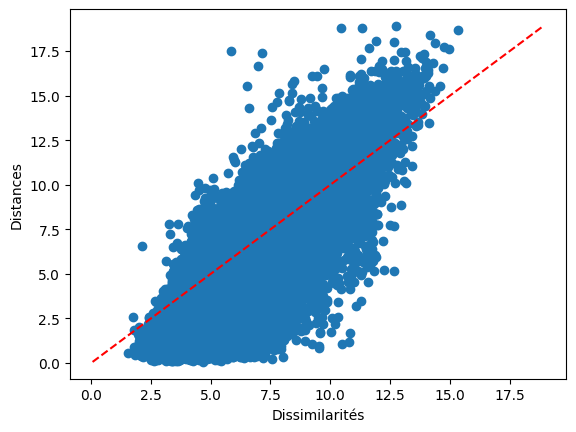

In [40]:
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

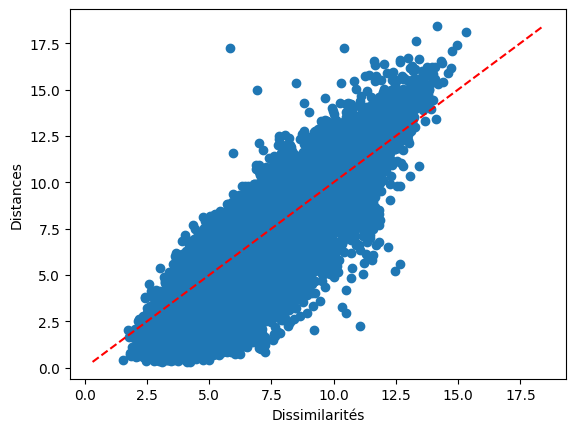

In [41]:
aftd = MDS(n_components=3, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

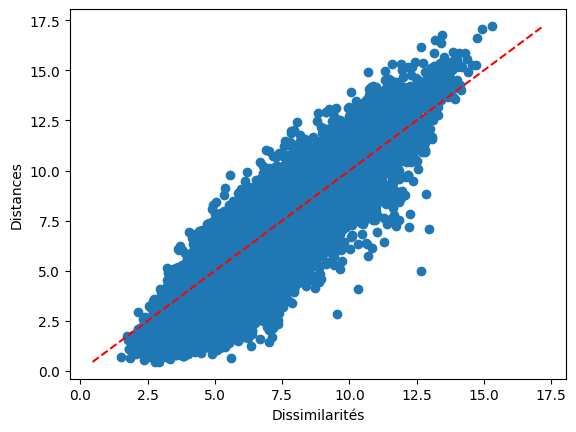

In [42]:
aftd = MDS(n_components=4, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

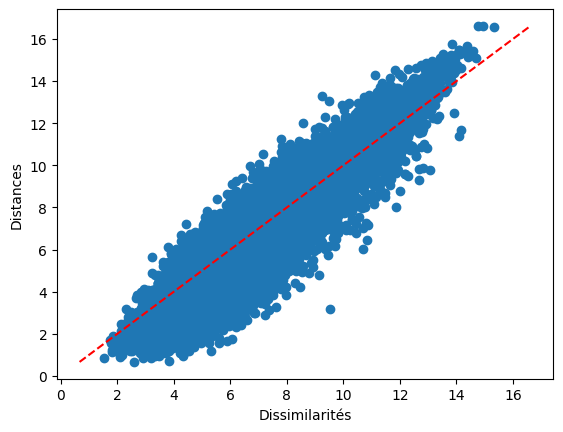

In [43]:
aftd = MDS(n_components=5, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

In [47]:
stress_shepard = aftd.stress_
print(f"Stress théorique = {stress_shepard}")
diss, dist = plot_Shepard(aftd, plot=False)
stress_exp = np.sum((diss - dist)**2)
print(f"Stress théorique = {stress_exp}")

Stress théorique = 43702.77341726476
Stress théorique = 43693.609741669694


In [50]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    default_kwargs = dict(leaf_font_size=10)
    default_kwargs.update(kwargs or {})
        
    dendrogram(linkage_matrix, **default_kwargs)


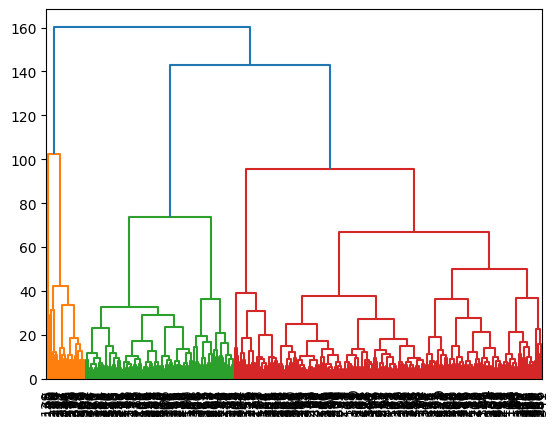

In [53]:
# CAH
cls = AgglomerativeClustering( metric="euclidean", linkage="ward", distance_threshold=0,n_clusters=None)
cls.fit(data)
plot_dendrogram(cls)
plt.show()